In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

fmena14_crowd_counting_path = kagglehub.dataset_download('fmena14/crowd-counting')
krishd8001_people_count_path = kagglehub.dataset_download('krishd8001/people-count')

print('Data source import complete.')

Data source import complete.


In [ ]:
# pip install ultralytics

In [ ]:
# ------------------------
# Import Libraries
# ------------------------
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import random
import matplotlib.pyplot as plt
import os
import seaborn as sns # Import the seaborn library
from ultralytics import YOLO
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [ ]:
csv_path = '/kaggle/working/people_counts.csv'
img_path = '/kaggle/input/crowd-counting/images.npy'
npy_path = '/kaggle/working/people_counts.npy'

In [ ]:
# Load images
img = np.load('/kaggle/input/crowd-counting/images.npy')
print(f"Loaded {img.shape[0]} images")

# YOLO model
model = YOLO('yolov8m.pt')  # Balanced accuracy vs speed

# Clean images — ensure same shape (480, 640, 3) and uint8
expected_shape = (480, 640, 3)
cleaned_images = []
valid_indices = []

for idx, im in enumerate(img):
    if im.shape == expected_shape and im.dtype == np.uint8:
        cleaned_images.append(im)
        valid_indices.append(idx)
    else:
        print(f"Skipping image {idx}: shape {im.shape}, dtype {im.dtype}")

# Batch predict
batch_size = 8
results_list = []

for i in range(0, len(cleaned_images), batch_size):
    batch = cleaned_images[i:i+batch_size]
    results = model.predict(source=batch, classes=[0], conf=0.25, imgsz=960, verbose=False)

    for j, r in enumerate(results):
        boxes = r.boxes.xyxy.cpu().numpy()
        people_count = len(boxes)
        true_idx = valid_indices[i + j]  # original image index
        results_list.append({'image_id': true_idx, 'people_detected': people_count})

    print(f"Processed {min(i + batch_size, len(cleaned_images))}/{len(cleaned_images)} images")

# Save CSV
df = pd.DataFrame(results_list)
csv_path = 'people_counts.csv'
df.to_csv(csv_path, index=False)
print(f"\n People counts saved to: {csv_path}")

Loaded 2000 images


100%|██████████| 49.7M/49.7M [00:00<00:00, 421MB/s]


Processed 8/2000 images
Processed 16/2000 images
Processed 24/2000 images
Processed 32/2000 images
Processed 40/2000 images
Processed 48/2000 images
Processed 56/2000 images
Processed 64/2000 images
Processed 72/2000 images
Processed 80/2000 images
Processed 88/2000 images
Processed 96/2000 images
Processed 104/2000 images
Processed 112/2000 images
Processed 120/2000 images
Processed 128/2000 images
Processed 136/2000 images
Processed 144/2000 images
Processed 152/2000 images
Processed 160/2000 images
Processed 168/2000 images
Processed 176/2000 images
Processed 184/2000 images
Processed 192/2000 images
Processed 200/2000 images
Processed 208/2000 images
Processed 216/2000 images
Processed 224/2000 images
Processed 232/2000 images
Processed 240/2000 images
Processed 248/2000 images
Processed 256/2000 images
Processed 264/2000 images
Processed 272/2000 images
Processed 280/2000 images
Processed 288/2000 images
Processed 296/2000 images
Processed 304/2000 images
Processed 312/2000 images

In [ ]:
# Step 1: Load CSV
csv_path = 'people_counts.csv'
label_df = pd.read_csv(csv_path)
label_df.columns = ['id', 'people']  # Ensure consistent column names

# Step 2: Convert 'people' column to NumPy array
labels = np.array(label_df['people'], dtype=np.int32)

# Step 3: Save to .npy file
npy_path = 'people_counts.npy'
np.save(npy_path, labels)
print(f"Saved labels to .npy: {npy_path}")

# Step 4: Load images
img_path = '/kaggle/input/crowd-counting/images.npy'
img = np.load(img_path)  # shape: (num_samples, 480, 640, 3)
print(f"Shape of images array: {img.shape}")

# Step 5: Load the saved .npy labels
loaded_labels = np.load(npy_path)
print(f"Shape of labels array: {loaded_labels.shape}")

# Step 6: Quick check
print("First 10 labels:", loaded_labels[:10])

Saved labels to .npy: people_counts.npy
Shape of images array: (2000, 480, 640, 3)
Shape of labels array: (2000,)
First 10 labels: [21 28 25 28 29 27 17 26 18 16]


In [ ]:
# Step 7: Labels statistics
labels_df = pd.DataFrame(loaded_labels, columns=['people'])
print("Labels Statistics Summary:")
print(labels_df.describe())

Labels Statistics Summary:
            people
count  2000.000000
mean     20.173500
std       4.778788
min       5.000000
25%      17.000000
50%      20.000000
75%      23.000000
max      36.000000


In [ ]:
# ------------------------
# Load the Data
# ------------------------

# Load labels
label_df = pd.read_csv('people_counts.csv')
label_df.columns = ['id', 'people']  # Rename columns for clarity
print("Labels DataFrame head:")
display(label_df.head())

# Load images
img = np.load('/kaggle/input/crowd-counting/images.npy')  # shape: (num_samples, 480, 640, 3)
print(f"Shape of images array: {img.shape}")

# Convert labels to numpy array
labels = np.array(label_df['people'])
print(f"Shape of labels array: {labels.shape}")

# Quick check
print("First 10 labels:", labels[:10])

Labels DataFrame head:


,id,people
0,0,21
1,1,28
2,2,25
3,3,28
4,4,29


Shape of images array: (2000, 480, 640, 3)
Shape of labels array: (2000,)
First 10 labels: [21 28 25 28 29 27 17 26 18 16]


In [ ]:
# ------------------------
# Basic statistics
# ------------------------
labels_df = pd.DataFrame(labels, columns=['people'])

print("Labels Statistics Summary:")
display(labels_df.describe())

Labels Statistics Summary:


,people
count,2000.000000
mean,20.173500
std,4.778788
min,5.000000
25%,17.000000
50%,20.000000
75%,23.000000
max,36.000000


<ipython-input-13-bb5073be92d4>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(labels, bins=30, color='purple', kde=True, hist=True)


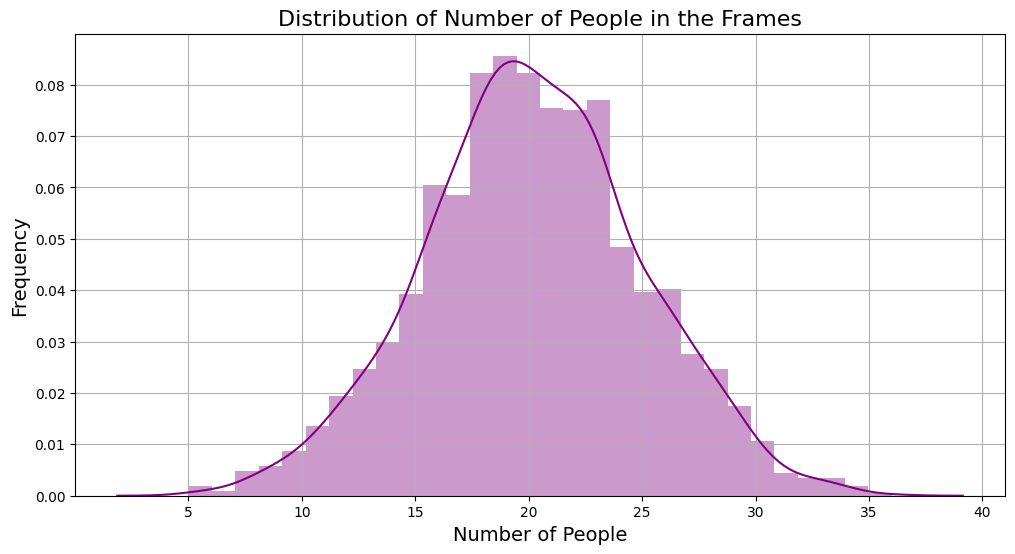

In [ ]:
# ------------------------
#  Visualize distribution
# ------------------------
plt.figure(figsize=(12,6))
sns.distplot(labels, bins=30, color='purple', kde=True, hist=True)
plt.title('Distribution of Number of People in the Frames', fontsize=16)
plt.xlabel('Number of People', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True)
plt.show()

In [ ]:
# ------------------------
#  Find Min and Max
# ------------------------
print(f"Minimum number of people in any frame: {labels.min()}")
print(f"Maximum number of people in any frame: {labels.max()}")

Minimum number of people in any frame: 5
Maximum number of people in any frame: 36


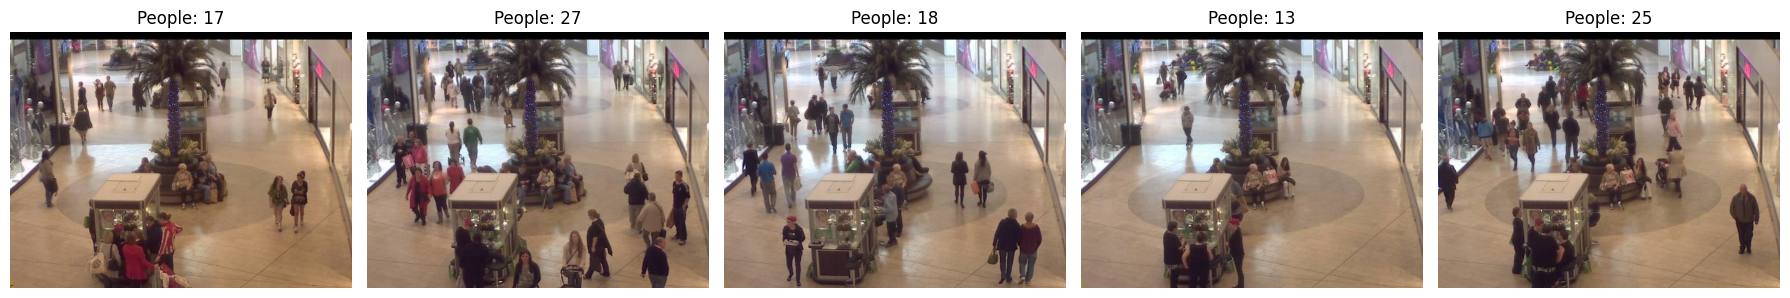

In [ ]:
# ------------------------
#  Show some sample images
# ------------------------
import random

# Randomly pick 5 images
indices = random.sample(range(img.shape[0]), 5)

plt.figure(figsize=(18,5))
for i, idx in enumerate(indices):
    plt.subplot(1,5,i+1)
    plt.imshow(img[idx].astype('uint8'))
    plt.title(f"People: {labels[idx]}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

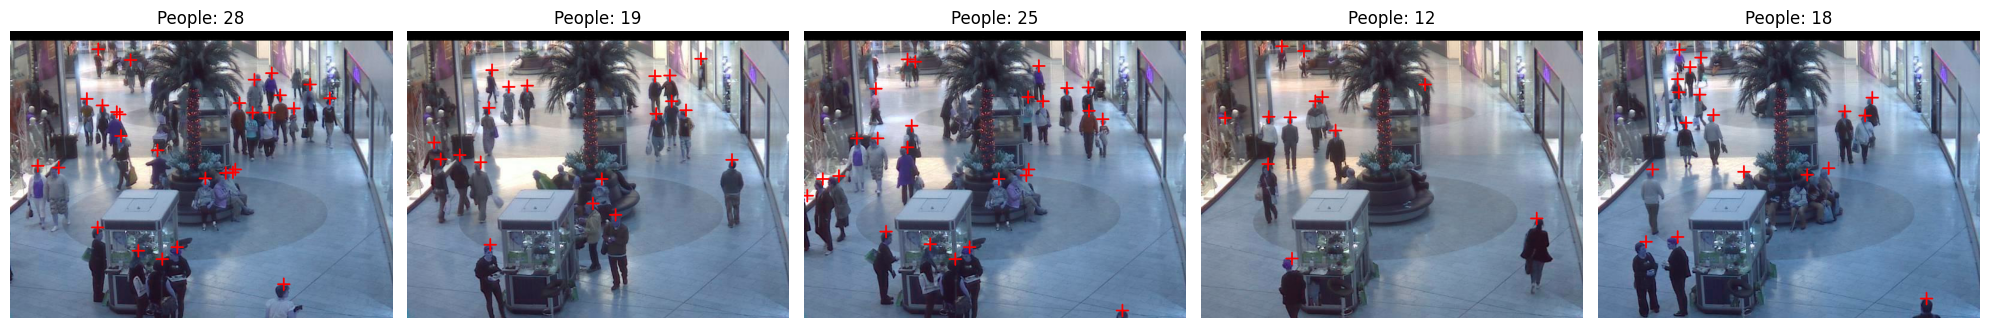

In [ ]:
import cv2
import random

# Load people counts
df = pd.read_csv('people_counts.csv')

# Display 5 random images with detection results
random_indices = random.sample(range(img.shape[0]), 5)

plt.figure(figsize=(20, 6))
for i, idx in enumerate(random_indices):
    image = img[idx].copy()
    results = model.predict(source=image, classes=[0], conf=0.25, imgsz=960, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    # Draw red crosses on heads
    for (x1, y1, x2, y2) in boxes:
        center_x = int((x1 + x2) / 2)
        head_y = int(y1)
        cv2.line(image, (center_x - 10, head_y), (center_x + 10, head_y), (0, 0, 255), 2)
        cv2.line(image, (center_x, head_y - 10), (center_x, head_y + 10), (0, 0, 255), 2)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    count = df[df['image_id'] == idx]['people_detected'].values[0]

    plt.subplot(1, 5, i + 1)
    plt.imshow(image_rgb)
    plt.title(f"People: {count}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Binary classification based on mean value
threshold = 20
labels_class = np.where(labels > threshold, 1, 0)  # 1 = Crowded, 0 = Non-Crowded

# Quick check
unique, counts = np.unique(labels_class, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(1071), np.int64(1): np.int64(929)}


In [ ]:
import tensorflow as tf

# Resize images
img_resized = tf.image.resize(img, (224, 224)).numpy()
print(img_resized.shape)

(2000, 224, 224, 3)


In [ ]:
img_resized = img_resized / 255.0

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(img_resized, labels_class, test_size=0.2, random_state=42, stratify=labels_class)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 1600
Testing samples: 400


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Create an ImageDataGenerator for augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Apply only simple normalization to validation data (NO augmentation)
valid_datagen = ImageDataGenerator()

# Create train and validation generators
train_gen = train_datagen.flow(X_train, y_train, batch_size=32)
valid_gen = valid_datagen.flow(X_test, y_test, batch_size=32)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Output 0/1
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


FailedPreconditionError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-pa

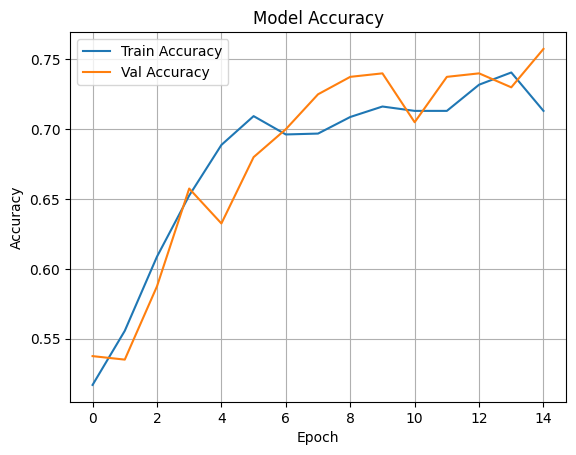

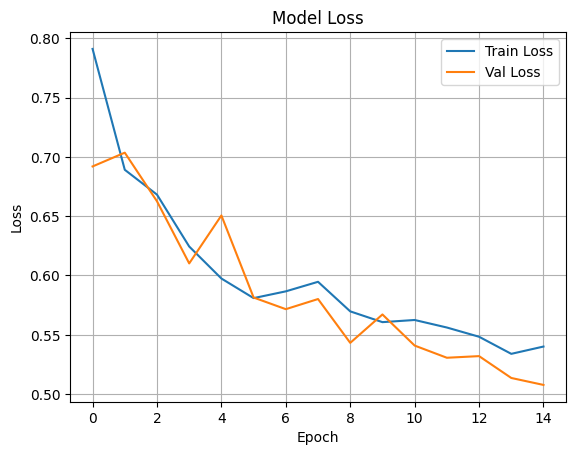

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(valid_gen, verbose=1)

# Print the results
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7830 - loss: 0.4955
Test Loss: 0.5077
Test Accuracy: 0.7575


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load the MobileNetV2 model, pretrained on ImageNet, excluding the top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model so its weights are not updated during training
base_model.trainable = False

# Build the new model on top of the base MobileNetV2 model
model_mobilenet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model_mobilenet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_mobilenet.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Training MobileNetV2
history_mobilenet = model_mobilenet.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 413ms/step - accuracy: 0.6364 - loss: 0.7592 - val_accuracy: 0.7800 - val_loss: 0.4675
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 291ms/step - accuracy: 0.7096 - loss: 0.5343 - val_accuracy: 0.7950 - val_loss: 0.4509
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 292ms/step - accuracy: 0.7248 - loss: 0.5299 - val_accuracy: 0.7875 - val_loss: 0.4404
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 287ms/step - accuracy: 0.7710 - loss: 0.4485 - val_accuracy: 0.7975 - val_loss: 0.4378
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 289ms/step - accuracy: 0.7879 - loss: 0.4395 - val_accuracy: 0.8025 - val_loss: 0.4205
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 294ms/step - accuracy: 0.8206 - loss: 0.4231 - val_accuracy: 0.7725 - val_loss: 0.4454
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 311ms/step - accuracy: 0.7972 - loss: 0.4407 - val_accuracy: 0.8050 - val_loss: 0.4066
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 296ms/step - accuracy: 0.7960 - loss: 0.4407 - val_accu

In [ ]:
# Evaluate MobileNetV2
loss_mobilenet, accuracy_mobilenet = model_mobilenet.evaluate(valid_gen, verbose=1)
print(f"MobileNetV2 Test Loss: {loss_mobilenet:.4f}")
print(f"MobileNetV2 Test Accuracy: {accuracy_mobilenet:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7891 - loss: 0.4091
MobileNetV2 Test Loss: 0.3892
MobileNetV2 Test Accuracy: 0.8125


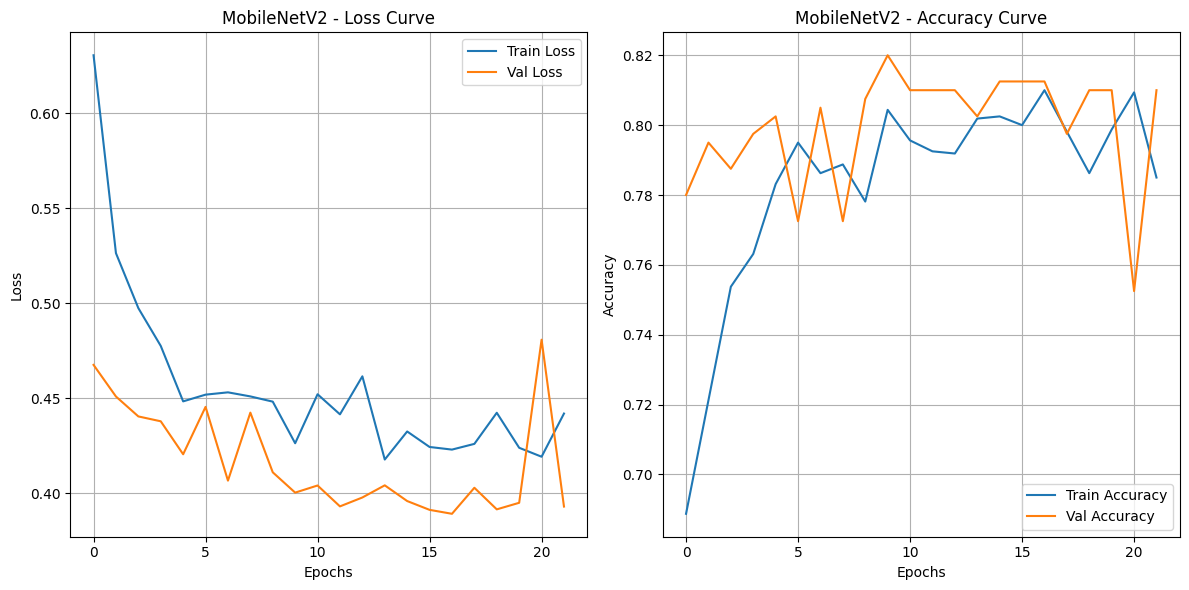

In [ ]:
# Plot Loss curve for MobileNetV2
plt.figure(figsize=(12, 6))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Val Loss')
plt.title('MobileNetV2 - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Val Accuracy')
plt.title('MobileNetV2 - Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


Classification Report:
                 precision    recall  f1-score   support

Non-Crowded (0)       0.80      0.87      0.84       827
    Crowded (1)       0.84      0.75      0.79       709

       accuracy                           0.82      1536
      macro avg       0.82      0.81      0.81      1536
   weighted avg       0.82      0.82      0.82      1536



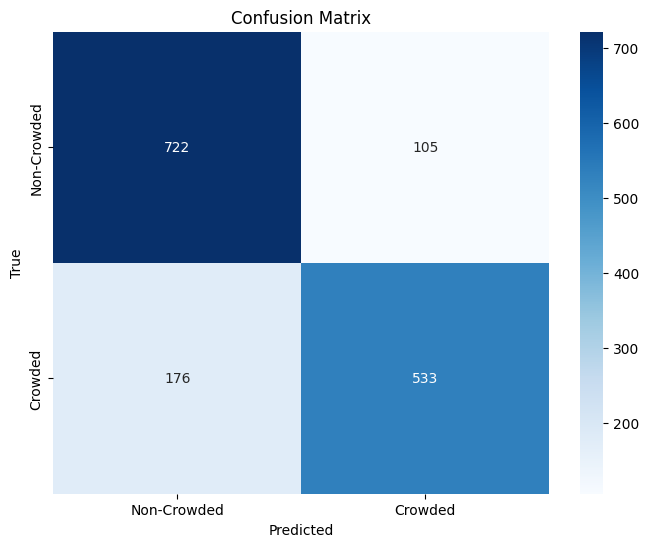

In [ ]:
# Generate predictions for classification report and confusion matrix
y_pred = []
y_true = []
for i in range(len(X_test) // batch_size):
    x_batch, y_batch = next(valid_gen)
    preds = model_mobilenet.predict(x_batch, verbose=0)
    y_pred.extend((preds >= 0.5).astype(int).flatten())
    y_true.extend(y_batch.astype(int))
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Non-Crowded (0)', 'Crowded (1)']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Crowded', 'Crowded'], yticklabels=['Non-Crowded', 'Crowded'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


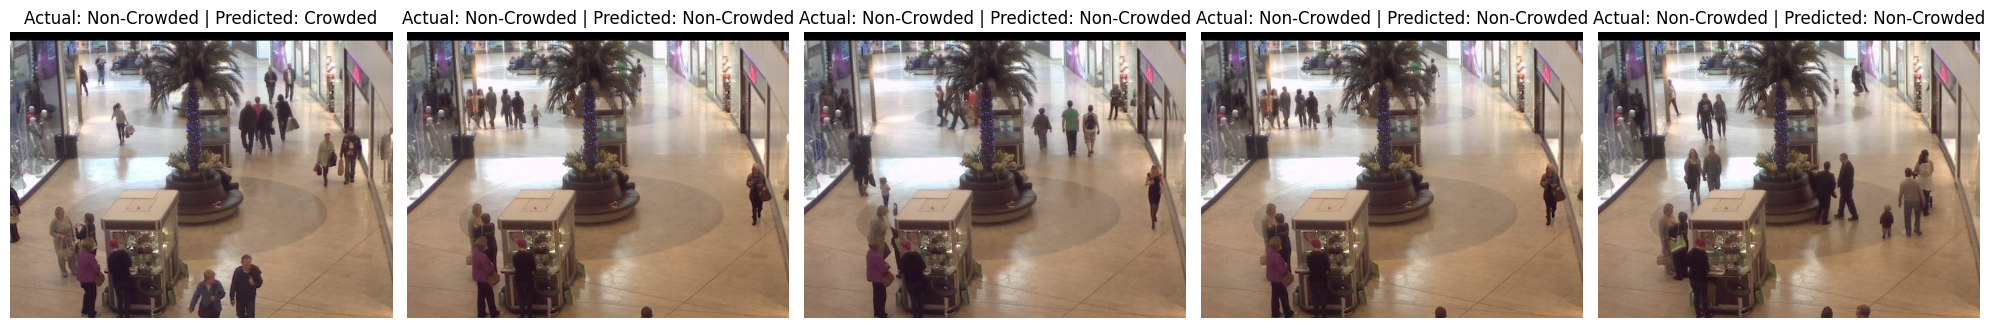

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)  # Resize image to 224x224
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)  # Preprocess the image
    return img_array
def preprocess_image(img_array, target_size=(224, 224)):
    # Resize and normalize for MobileNetV2
    img_resized = tf.image.resize(img_array, target_size).numpy()
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array
# Number of images to plot
num_images_to_plot = 5  # Set how many images you want to display

# Create a figure to plot multiple images
plt.figure(figsize=(20, 15))

# Loop through the images
for img_index in range(num_images_to_plot):
    # Generate the image filename
    img_filename = 'seq_' + str(label_df.iloc[img_index, 1]).zfill(6) + '.jpg'  # Zero-padding to match filename format

    # Construct the correct image path
    img_path = '/kaggle/input/crowd-counting/frames/frames/' + img_filename

    # Load and preprocess the image
    preprocessed_image = load_and_preprocess_image(img_path)

    # Predict the number of people in the image
    prediction = model_mobilenet.predict(preprocessed_image)

    # Round the prediction to get a binary label (Crowded: 1, Non-Crowded: 0)
    predicted_label = 'Crowded' if prediction >= 0.5 else 'Non-Crowded'

    # Get the actual label
    actual_label = 'Crowded' if labels[img_index] >= 31 else 'Non-Crowded'

    # Load the image for visualization
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for correct plotting

    # Plot the image
    plt.subplot(1, num_images_to_plot, img_index + 1)  # Create a subplot for each image
    plt.imshow(img)
    plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}", fontsize=12)
    plt.axis('off')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

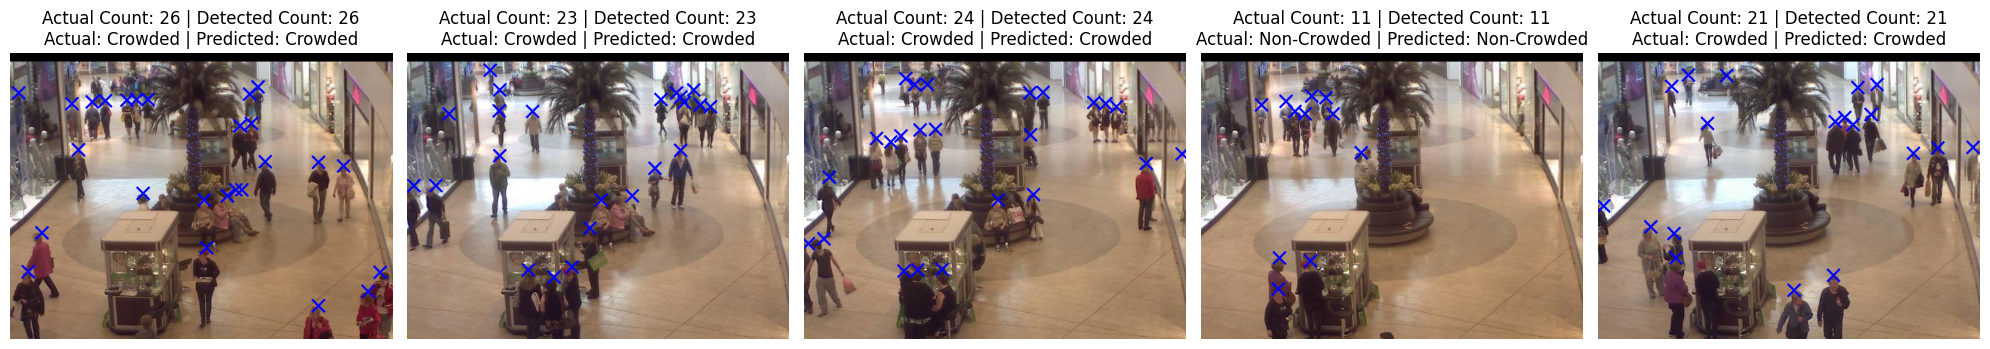

In [ ]:
# Visualize 5 random images
num_images_to_plot = 5
random_indices = np.random.choice(img.shape[0], size=num_images_to_plot, replace=False)
plt.figure(figsize=(20, 15))

for i, img_index in enumerate(random_indices):
    # Get image and labels
    img_array = img[img_index]
    img_id = label_df.iloc[img_index, 0]
    actual_count = label_df.iloc[img_index, 1]
    actual_label = 'Crowded' if actual_count >= 20 else 'Non-Crowded'

    # Predict with MobileNetV2
    preprocessed_image = preprocess_image(img_array)
    prediction = model_mobilenet.predict(preprocessed_image, verbose=0)[0][0]
    predicted_label = 'Crowded' if prediction >= 0.5 else 'Non-Crowded'

    # Detect people with YOLOv8
    yolo_results = yolo_model(img_array, classes=[0], conf=0.25, imgsz=960, verbose=False)[0]
    img_cv = img_array.copy()
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)  # Ensure correct color channels

    # Draw red crosses on detected heads
    for box in yolo_results.boxes.xyxy:
        x1, y1, x2, y2 = map(int, box.tolist())
        cx, cy = (x1 + x2) // 2, y1  # Use top of box for head
        cv2.drawMarker(img_rgb, (cx, cy), color=(255, 0, 0),
                       markerType=cv2.MARKER_TILTED_CROSS, markerSize=20, thickness=2)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)  # Convert back for plotting

    # Get YOLO-detected people count
    detected_count = len(yolo_results.boxes.xyxy)

    # Plot
    plt.subplot(1, num_images_to_plot, i + 1)
    plt.imshow(img_rgb)
    plt.title(
        f"Actual Count: {actual_count} | Detected Count: {detected_count}\n"
        f"Actual: {actual_label} | Predicted: {predicted_label}",
        fontsize=12
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Save the MobileNetV2 model
model_mobilenet.save('/kaggle/working/model_mobilenet.h5')
print("MobileNetV2 model saved to /kaggle/working/model_mobilenet.h5")

MobileNetV2 model saved to /kaggle/working/model_mobilenet.h5


In [ ]:
# If images were resized to (224, 224, 3), we reshape them to (224 time steps, 224x3 features)
X_train_seq = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]*X_train.shape[3]))
X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]*X_test.shape[3]))

print("Training Sequence Shape:", X_train_seq.shape)
print("Testing Sequence Shape:", X_test_seq.shape)

Training Sequence Shape: (1600, 224, 672)
Testing Sequence Shape: (400, 224, 672)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# Build a simple RNN model
rnn_model = Sequential([
    SimpleRNN(128, activation='tanh', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 128)                 │         102,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,849 (433.00 KB)

 Trainable params: 110,849 (433.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train RNN model
history_rnn = rnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_test_seq, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.4995 - loss: 0.7583 - val_accuracy: 0.4650 - val_loss: 0.6943
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5449 - loss: 0.7083 - val_accuracy: 0.5350 - val_loss: 0.6879
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5337 - loss: 0.7086 - val_accuracy: 0.4650 - val_loss: 0.6952
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5321 - loss: 0.6955 - val_accuracy: 0.5375 - val_loss: 0.6896
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5662 - loss: 0.6875 - val_accuracy: 0.4650 - val_loss: 0.6933
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5147 - loss: 0.6954 - val_accuracy: 0.6375 - val_loss: 0.6910
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5453 - loss: 0.6887 - val_accuracy: 0.5950 - val_loss: 0.6802
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5587 - loss: 0.6833 - val_accuracy: 0.6200 - v

In [ ]:
# Evaluate on test set
loss_rnn, accuracy_rnn = rnn_model.evaluate(X_test_seq, y_test, verbose=1)

print(f"RNN Test Loss: {loss_rnn:.4f}")
print(f"RNN Test Accuracy: {accuracy_rnn:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6851 - loss: 0.6161
RNN Test Loss: 0.6235
RNN Test Accuracy: 0.6725


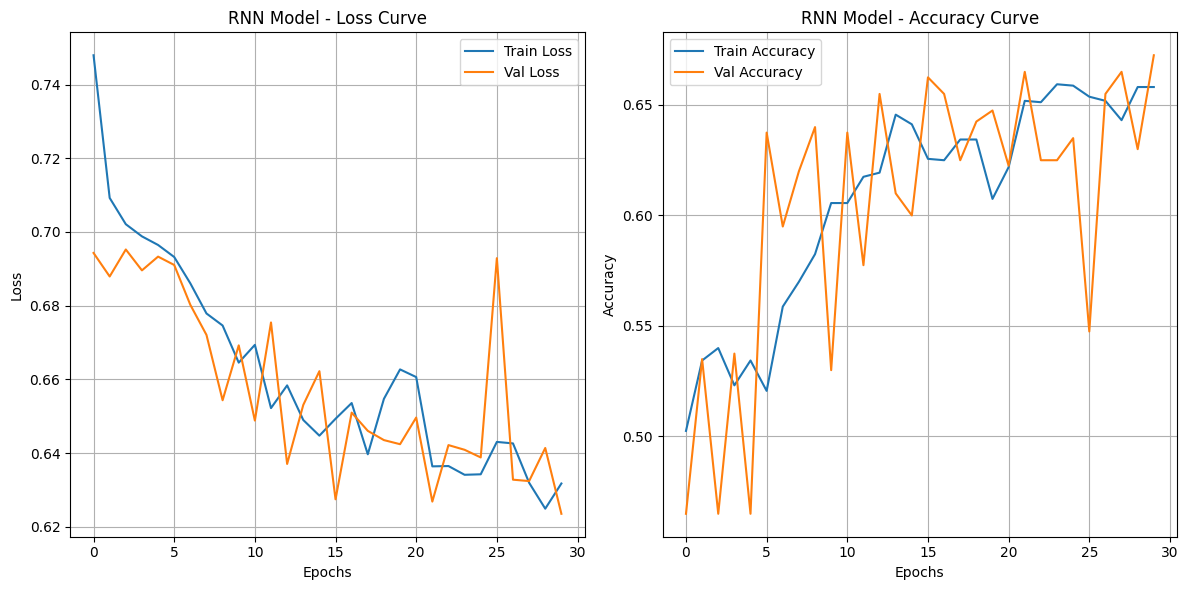

In [ ]:
# Plotting the Loss and Accuracy Curves
plt.figure(figsize=(12, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('RNN Model - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Val Accuracy')
plt.title('RNN Model - Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Custom Generator for LSTM
def lstm_generator(image_generator):
    while True:
        imgs, labels = next(image_generator)
        # Reshape for LSTM input: (batch, time_steps, features)
        imgs_seq = imgs.reshape(imgs.shape[0], imgs.shape[1], imgs.shape[2]*imgs.shape[3])
        yield imgs_seq, labels

In [ ]:
train_lstm_gen = lstm_generator(train_gen)
valid_lstm_gen = lstm_generator(valid_gen)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM Model
lstm_model = Sequential([
    LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]*X_train.shape[3]), return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # Binary classification (Crowded/Not Crowded)
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 128)                 │         410,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 418,433 (1.60 MB)

 Trainable params: 418,433 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = lstm_model.fit(
    train_lstm_gen,
    validation_data=valid_lstm_gen,
    steps_per_epoch=len(X_train)//32,
    validation_steps=len(X_test)//32,
    epochs=15,
    verbose=1
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 288ms/step - accuracy: 0.5375 - loss: 0.7193 - val_accuracy: 0.5234 - val_loss: 0.6923
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.4936 - loss: 0.7074 - val_accuracy: 0.4661 - val_loss: 0.6938
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 284ms/step - accuracy: 0.5123 - loss: 0.6928 - val_accuracy: 0.5489 - val_loss: 0.6881
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 284ms/step - accuracy: 0.5071 - loss: 0.7010 - val_accuracy: 0.5543 - val_loss: 0.6869
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 281ms/step - accuracy: 0.5123 - loss: 0.6934 - val_accuracy: 0.5109 - val_loss: 0.6896
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 284ms/step - accuracy: 0.5025 - loss: 0.6961 - val_accuracy: 0.6359 - val_loss: 0.6867
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 283ms/step - accuracy: 0.5644 - loss: 0.6854 - val_accuracy: 0.5734 - val_loss: 0.6877
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - accuracy: 0.5308 - loss: 0.6920 - val_accu

In [ ]:
# Evaluate on validation/test set
loss_lstm, accuracy_lstm = lstm_model.evaluate(valid_lstm_gen, steps=len(X_test)//32)

print(f"LSTM Test Loss: {loss_lstm:.4f}")
print(f"LSTM Test Accuracy: {accuracy_lstm:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6633 - loss: 0.6447
LSTM Test Loss: 0.6524
LSTM Test Accuracy: 0.6630


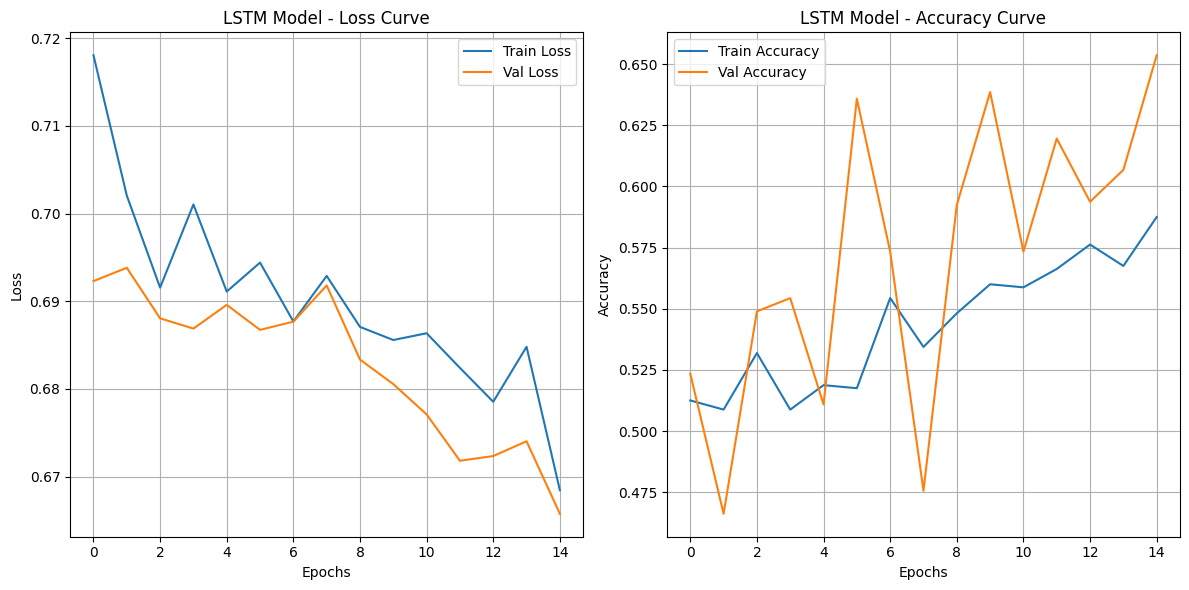

In [ ]:
# Plotting Loss and Accuracy
plt.figure(figsize=(12, 6))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Model - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Model - Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
yolo_model_path = '/kaggle/working/yolov8m.pt'

In [ ]:
# Check and upload files
print("Checking file paths:")
print(f"Images .npy exists: {os.path.exists(img_path)}")
print(f"CSV exists: {os.path.exists(csv_path)}")
print(f"YOLO model exists: {os.path.exists(yolo_model_path)}")
if not os.path.exists(img_path) or not os.path.exists(csv_path):
    print("Files not found! Uploading...")
    from google.colab import files
    uploaded = files.upload()
    print("Uploaded files:", list(uploaded.keys()))
if not os.path.exists(yolo_model_path):
    print("YOLOv8m model not found! Please upload yolov8m.pt")
    from google.colab import files
    uploaded = files.upload()
    print("Uploaded files:", list(uploaded.keys()))

Checking file paths:
Images .npy exists: True
CSV exists: True
YOLO model exists: True


In [ ]:
# Load labels
try:
    label_df = pd.read_csv(csv_path)
    label_df.columns = ['id', 'people']
    labels = np.array(label_df['people'], dtype=np.int32)
    print(f"Loaded labels: {label_df.shape}")
except Exception as e:
    print(f"Error loading CSV: {e}")
    raise

Loaded labels: (2000, 2)


In [ ]:
try:
    img = np.load(img_path)
    print(f"Loaded images: {img.shape}")
except Exception as e:
    print(f"Error loading images: {e}")
    raise

Loaded images: (2000, 480, 640, 3)


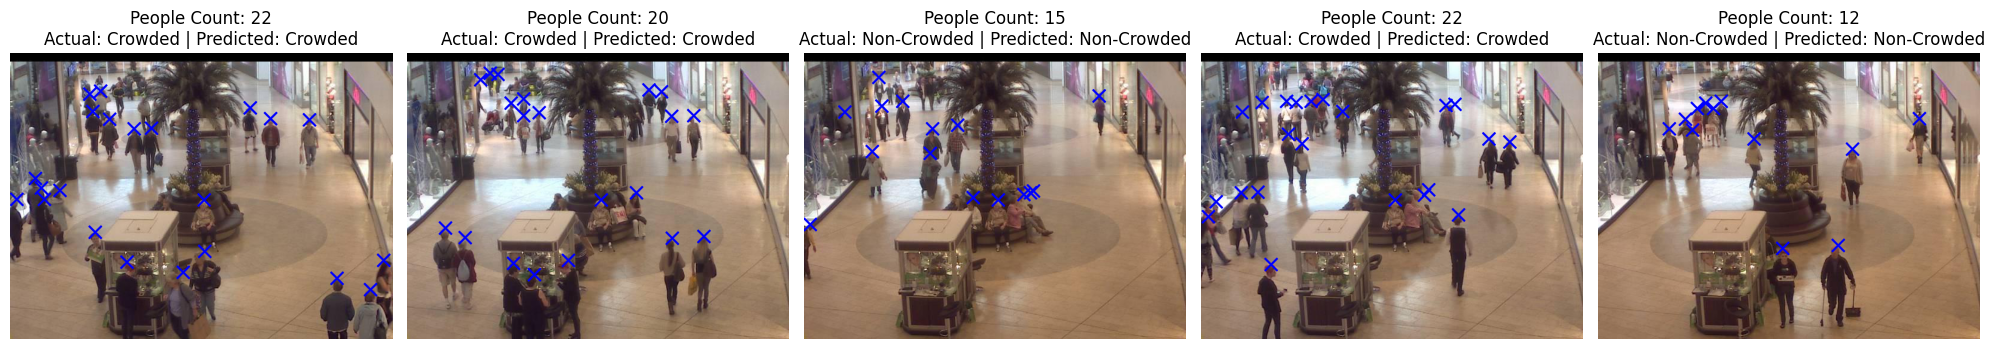

In [ ]:
def preprocess_image(img_array, target_size=(224, 224)):
    # Resize and normalize for MobileNetV2
    img_resized = tf.image.resize(img_array, target_size).numpy()
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Visualize 5 random images
num_images_to_plot = 5
random_indices = np.random.choice(img.shape[0], size=num_images_to_plot, replace=False)
plt.figure(figsize=(20, 15))

for i, img_index in enumerate(random_indices):
    # Get image and label
    img_array = img[img_index]
    img_id = label_df.iloc[img_index, 0]
    actual_count = label_df.iloc[img_index, 1]
    actual_label = 'Crowded' if actual_count >= 20 else 'Non-Crowded'

    # Predict with MobileNetV2
    preprocessed_image = preprocess_image(img_array)
    prediction = model_mobilenet.predict(preprocessed_image, verbose=0)[0][0]
    predicted_label = 'Crowded' if prediction >= 0.5 else 'Non-Crowded'

    # Detect people with YOLOv8
    yolo_results = yolo_model(img_array, classes=[0], conf=0.25, imgsz=960, verbose=False)[0]
    img_cv = img_array.copy()
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)  # Ensure correct color channels

    # Draw red crosses on detected people
    for box in yolo_results.boxes.xyxy:
        x1, y1, x2, y2 = map(int, box.tolist())
        cx, cy = (x1 + x2) // 2, y1  # Use top of box for head
        cv2.drawMarker(img_rgb, (cx, cy), color=(255, 0, 0),
                       markerType=cv2.MARKER_TILTED_CROSS, markerSize=20, thickness=2)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)  # Convert back for plotting

    # Plot
    plt.subplot(1, num_images_to_plot, i + 1)
    plt.imshow(img_rgb)
    plt.title(
        f"People Count: {actual_count}\n"
        f"Actual: {actual_label} | Predicted: {predicted_label}",
        fontsize=12
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

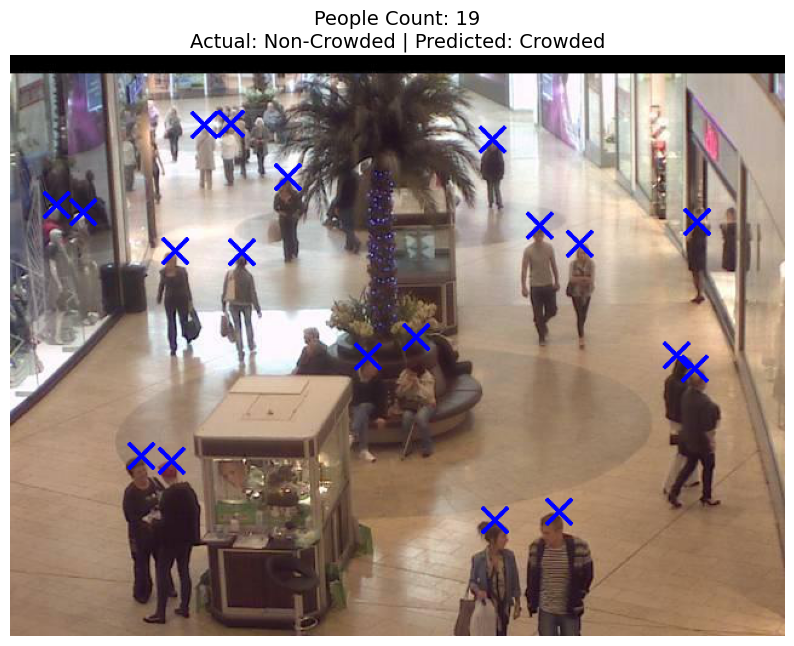

In [ ]:
# Select and process a random image
img_index = np.random.randint(0, img.shape[0])
img_array = img[img_index]
img_id = label_df.iloc[img_index, 0]
actual_count = label_df.iloc[img_index, 1]
actual_label = 'Crowded' if actual_count >= 20 else 'Non-Crowded'

# Classify using MobileNetV2
preprocessed_image = preprocess_image(img_array)
prediction = model_mobilenet.predict(preprocessed_image, verbose=0)[0][0]
predicted_label = 'Crowded' if prediction >= 0.5 else 'Non-Crowded'

# Detect people with YOLO
yolo_results = yolo_model(img_array, classes=[0], conf=0.25, imgsz=960, verbose=False)[0]
img_cv = img_array.copy()
img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)  # Ensure correct color channels

# Draw red crosses on detected people
for box in yolo_results.boxes.xyxy:
    x1, y1, x2, y2 = map(int, box.tolist())
    cx, cy = (x1 + x2) // 2, y1  # Use top of box for head
    cv2.drawMarker(img_rgb, (cx, cy), color=(255, 0, 0),
                   markerType=cv2.MARKER_TILTED_CROSS, markerSize=20, thickness=2)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)  # Convert back for plotting

# Display
people_count = len(yolo_results.boxes.xyxy)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title(f"People Count: {people_count}\nActual: {actual_label} | Predicted: {predicted_label}", fontsize=14)
plt.axis('off')
plt.show()